# 06 — Flow Matching v2 (Improved)

Improved Flow Matching with attention-enhanced UNet, EMA, and better sampling.

**Improvements over v1:**
- Attention layers at 16x16 and 8x8 resolutions (following MOTFM paper)
- EMA (Exponential Moving Average) for stable generation
- Cosine learning rate schedule
- 100 epochs (2x v1)
- Adaptive ODE solver (dopri5) instead of fixed Euler steps

**Reference:** [Medical Optimal Transport Flow Matching](https://arxiv.org/abs/2503.00266)

## Setup

In [1]:
!pip install torchxrayvision torchcfm torchdiffeq -q
import os
import json
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy import linalg
import math

from torchdiffeq import odeint
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher

import torchxrayvision as xrv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.0 MB/s eta 0:00:00


2026-03-24 21:45:31.089326: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774388731.464864      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774388731.569086      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774388732.556818      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774388732.556861      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774388732.556864      25 computation_placer.cc:177] computation placer alr

Device: cuda


In [2]:
# hyperparameters — key changes from v1
IMG_SIZE = 64
CHANNELS = 1
BATCH_SIZE = 32
LR = 1e-4
N_EPOCHS = 100  # 2x v1 (MOTFM paper uses 200)
N_GENERATE = 100
EMA_DECAY = 0.999  # exponential moving average for stable generation

In [3]:
# paths
# DATA_DIR = Path("../data")  # for local use
DATA_DIR = Path("/kaggle/input/datasets/lakshyarathi/lungpp/data")
REAL_DIR = DATA_DIR / "pneumonia"

OUTPUT_DIR = Path("outputs/06_flow_matching_v2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## Dataset Loading

In [4]:
class XrayDataset(Dataset):
    def __init__(self, folder: Path, transform=None):
        self.paths = sorted([
            p for p in folder.iterdir()
            if p.suffix.lower() in {'.png', '.jpg', '.jpeg'} and not p.name.startswith('.')
        ])
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img

In [5]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # scale to [-1, 1]
])

dataset = XrayDataset(REAL_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size: 3875
Batches per epoch: 121


## Model Architecture

UNet with self-attention at 16x16 and 8x8 resolutions. Attention helps capture long-range dependencies in medical images (rib structures, lung boundaries).

In [6]:
class SinusoidalPosEmb(nn.Module):
    """Sinusoidal time embedding."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

In [7]:
class SelfAttention(nn.Module):
    """Self-attention for spatial features."""
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = channels // num_heads
        
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = self.head_dim ** -0.5
    
    def forward(self, x):
        b, c, h, w = x.shape
        residual = x
        x = self.norm(x)
        
        qkv = self.qkv(x).reshape(b, 3, self.num_heads, self.head_dim, h * w)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        
        # attention: (b, heads, head_dim, hw) @ (b, heads, hw, head_dim) -> (b, heads, hw, hw)
        attn = torch.einsum('bhdn,bhdm->bhnm', q, k) * self.scale
        attn = F.softmax(attn, dim=-1)
        
        # apply attention to values
        out = torch.einsum('bhnm,bhdm->bhdn', attn, v)
        out = out.reshape(b, c, h, w)
        out = self.proj(out)
        
        return out + residual

In [8]:
class ResBlock(nn.Module):
    """Residual block with time conditioning."""
    def __init__(self, in_ch, out_ch, time_emb_dim, dropout=0.1):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )
        
        self.block1 = nn.Sequential(
            nn.GroupNorm(min(8, in_ch), in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        self.block2 = nn.Sequential(
            nn.GroupNorm(min(8, out_ch), out_ch),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )
        self.residual_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.residual_conv(x)

In [9]:
class AttentionUNet(nn.Module):
    """
    UNet with self-attention at 16x16 and 8x8 resolutions.
    
    64 -> 32 -> 16 (attn) -> 8 (attn) -> 8 -> 16 -> 32 -> 64
    """
    def __init__(self, in_ch=1, base_ch=64, time_emb_dim=256):
        super().__init__()
        
        # time embedding MLP
        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.GELU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )
        
        # encoder
        self.enc1 = ResBlock(in_ch, base_ch, time_emb_dim)           # 64x64
        self.enc2 = ResBlock(base_ch, base_ch * 2, time_emb_dim)     # 32x32
        self.enc3 = ResBlock(base_ch * 2, base_ch * 4, time_emb_dim) # 16x16
        self.enc4 = ResBlock(base_ch * 4, base_ch * 4, time_emb_dim) # 8x8
        
        self.down1 = nn.Conv2d(base_ch, base_ch, 4, 2, 1)
        self.down2 = nn.Conv2d(base_ch * 2, base_ch * 2, 4, 2, 1)
        self.down3 = nn.Conv2d(base_ch * 4, base_ch * 4, 4, 2, 1)
        
        # attention at 16x16 and 8x8
        self.attn_enc3 = SelfAttention(base_ch * 4, num_heads=4)
        self.attn_enc4 = SelfAttention(base_ch * 4, num_heads=4)
        
        # bottleneck
        self.mid1 = ResBlock(base_ch * 4, base_ch * 4, time_emb_dim)
        self.mid_attn = SelfAttention(base_ch * 4, num_heads=4)
        self.mid2 = ResBlock(base_ch * 4, base_ch * 4, time_emb_dim)
        
        # decoder
        self.up4 = nn.ConvTranspose2d(base_ch * 4, base_ch * 4, 4, 2, 1)
        self.dec4 = ResBlock(base_ch * 8, base_ch * 4, time_emb_dim)
        self.attn_dec4 = SelfAttention(base_ch * 4, num_heads=4)
        
        self.up3 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 4, 2, 1)
        self.dec3 = ResBlock(base_ch * 4, base_ch * 2, time_emb_dim)
        
        self.up2 = nn.ConvTranspose2d(base_ch * 2, base_ch, 4, 2, 1)
        self.dec2 = ResBlock(base_ch * 2, base_ch, time_emb_dim)
        
        # output
        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_act = nn.SiLU()
        self.out = nn.Conv2d(base_ch, in_ch, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        
        # encoder
        e1 = self.enc1(x, t_emb)                      # 64x64
        e2 = self.enc2(self.down1(e1), t_emb)         # 32x32
        e3 = self.enc3(self.down2(e2), t_emb)         # 16x16
        e3 = self.attn_enc3(e3)
        e4 = self.enc4(self.down3(e3), t_emb)         # 8x8
        e4 = self.attn_enc4(e4)
        
        # bottleneck
        m = self.mid1(e4, t_emb)
        m = self.mid_attn(m)
        m = self.mid2(m, t_emb)
        
        # decoder
        d4 = self.dec4(torch.cat([self.up4(m), e3], dim=1), t_emb)  # 16x16
        d4 = self.attn_dec4(d4)
        d3 = self.dec3(torch.cat([self.up3(d4), e2], dim=1), t_emb) # 32x32
        d2 = self.dec2(torch.cat([self.up2(d3), e1], dim=1), t_emb) # 64x64
        
        return self.out(self.out_act(self.out_norm(d2)))

In [10]:
model = AttentionUNet(in_ch=CHANNELS, base_ch=64).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 12,318,787


In [11]:
# EMA model for stable generation
class EMA:
    """Exponential Moving Average of model weights."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()
    
    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = self.decay * self.shadow[name] + (1 - self.decay) * param.data
    
    def apply(self, model):
        """Apply EMA weights to model (for inference)."""
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]
    
    def restore(self, model):
        """Restore original weights."""
        for name, param in model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name]
        self.backup = {}

ema = EMA(model, decay=EMA_DECAY)

In [12]:
# flow matcher from torchcfm — sigma=0 for OT path
flow_matcher = ConditionalFlowMatcher(sigma=0.0)

## Training

In [13]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# cosine annealing LR schedule
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)

In [14]:
train_losses = []

print(f"Starting training for {N_EPOCHS} epochs...")

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    
    for batch_idx, x1 in enumerate(pbar):
        x1 = x1.to(device)  # target (real images)
        x0 = torch.randn_like(x1)  # source (noise)
        
        # sample time and compute flow matching target
        t, xt, ut = flow_matcher.sample_location_and_conditional_flow(x0, x1)
        t = t.to(device)
        xt = xt.to(device)
        ut = ut.to(device)
        
        # predict velocity field
        vt = model(xt, t)
        
        # MSE loss between predicted and target velocity
        loss = F.mse_loss(vt, ut)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        
        # update EMA
        ema.update(model)
        
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})
    
    scheduler.step()
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f}, lr={scheduler.get_last_lr()[0]:.2e}")
    
    # checkpoint every 20 epochs
    if (epoch + 1) % 20 == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch+1}.pt"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'ema_shadow': ema.shadow,
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_losses': train_losses,
        }, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

print("Training complete!")

Starting training for 100 epochs...


Epoch 1/100: 100%|██████████| 121/121 [00:22<00:00,  5.41it/s, loss=0.2434, lr=1.00e-04]


Epoch 1: loss=0.3312, lr=1.00e-04


Epoch 2/100: 100%|██████████| 121/121 [00:19<00:00,  6.09it/s, loss=0.1667, lr=1.00e-04]


Epoch 2: loss=0.1947, lr=9.99e-05


...

Epoch 98: loss=0.1095, lr=1.10e-06


Epoch 99/100: 100%|██████████| 121/121 [00:21<00:00,  5.64it/s, loss=0.0899, lr=1.10e-06]


Epoch 99: loss=0.1093, lr=1.02e-06


Epoch 100/100: 100%|██████████| 121/121 [00:21<00:00,  5.63it/s, loss=0.1116, lr=1.02e-06]


Epoch 100: loss=0.1095, lr=1.00e-06
Saved checkpoint: outputs/06_flow_matching_v2/checkpoints/checkpoint_epoch_100.pt
Training complete!


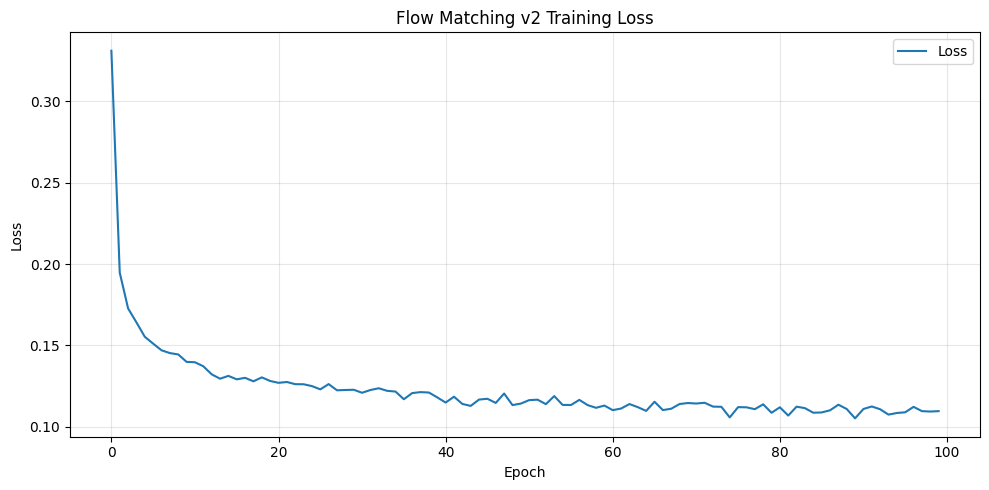

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Flow Matching v2 Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve.png", dpi=150)
plt.show()

## Generate 100 Images

In [16]:
generated_dir = OUTPUT_DIR / "images"
generated_dir.mkdir(parents=True, exist_ok=True)

# use EMA weights for generation
ema.apply(model)
model.eval()

generated_paths = []

In [17]:
class ODEFunc(nn.Module):
    """Wrapper for ODE solver."""
    def __init__(self, model):
        super().__init__()
        self.model = model
    
    def forward(self, t, x):
        t_batch = t.expand(x.shape[0])
        return self.model(x, t_batch)

In [18]:
ode_func = ODEFunc(model)

# generate in batches
batch_size = 10
n_batches = N_GENERATE // batch_size

for batch_idx in tqdm(range(n_batches), desc="Generating"):
    # start from noise
    torch.manual_seed(SEED + batch_idx)
    x0 = torch.randn(batch_size, CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
    
    # adaptive ODE solver (dopri5) — better quality than fixed Euler
    with torch.no_grad():
        t_span = torch.tensor([0.0, 1.0], device=device)
        x1 = odeint(ode_func, x0, t_span, method='dopri5', rtol=1e-5, atol=1e-5)[-1]
    
    for i, img_tensor in enumerate(x1):
        idx = batch_idx * batch_size + i
        img = img_tensor.squeeze().cpu().numpy()
        img = ((img + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
        img = Image.fromarray(img, mode='L')
        
        out_path = generated_dir / f"{idx:04d}.png"
        img.save(out_path, 'PNG')
        generated_paths.append(out_path)

# restore original weights
ema.restore(model)

print(f"Generated {len(generated_paths)} images")

Generating: 100%|██████████| 10/10 [00:24<00:00,  2.42s/it]

Generated 100 images


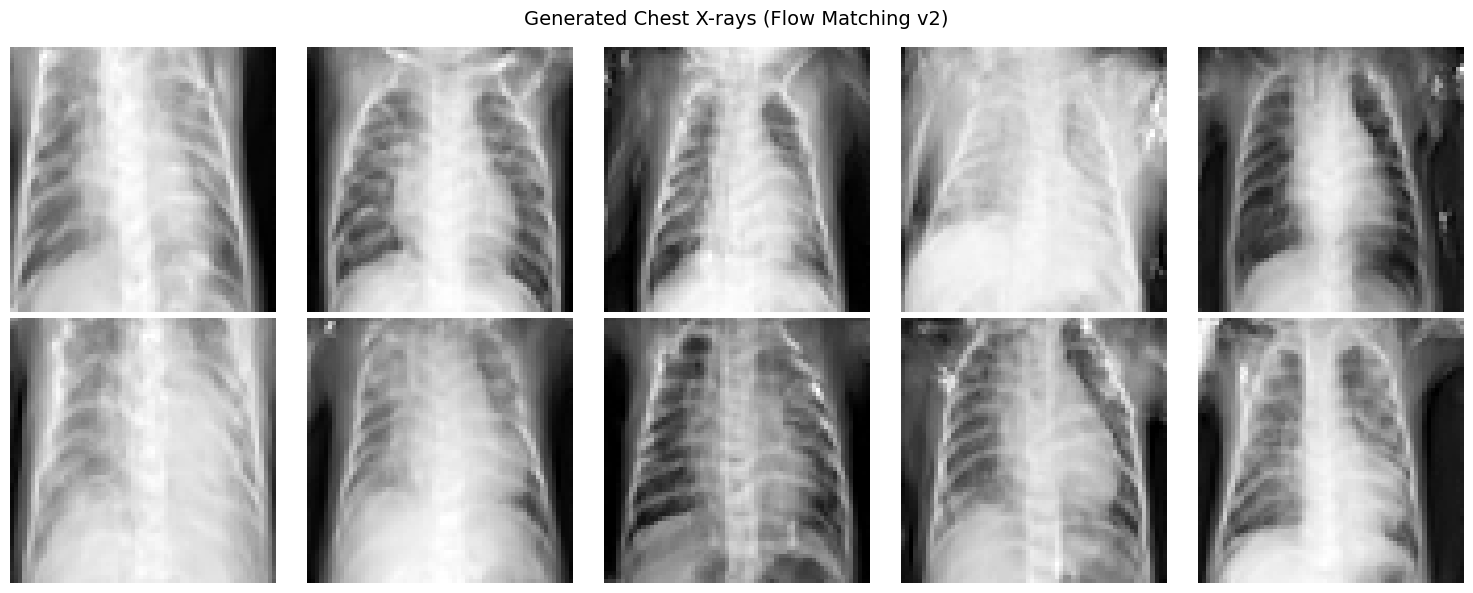

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Generated Chest X-rays (Flow Matching v2)", fontsize=14)

for ax, img_path in zip(axes.flat, generated_paths[:10]):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "generated_samples.png", dpi=150)
plt.show()

## Evaluate — FID (domain-adapted, DenseNet121 features)

In [20]:
xrv_model = xrv.models.DenseNet(weights="densenet121-res224-all")
xrv_model = xrv_model.to(device)
xrv_model.eval()

feature_extractor = nn.Sequential(*list(xrv_model.features.children()))
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


Sequential(
  (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(

In [21]:
def load_and_preprocess_for_xrv(img_path):
    img = Image.open(img_path).convert('L')
    img = img.resize((224, 224), Image.LANCZOS)
    img = np.array(img, dtype=np.float32)
    img = (img / 255.0) * 2048 - 1024
    img = img[np.newaxis, ...]
    return torch.tensor(img, dtype=torch.float32)


def extract_features(image_paths, batch_size=32):
    features = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            feat = feature_extractor(batch)
            feat = feat.mean(dim=[2, 3])
            features.append(feat.cpu().numpy())
    return np.concatenate(features, axis=0)


def compute_fid(real_features, fake_features):
    if len(real_features) < 2 or len(fake_features) < 2:
        return None
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)
    eps = 1e-6
    sigma_real += np.eye(sigma_real.shape[0]) * eps
    sigma_fake += np.eye(sigma_fake.shape[0]) * eps
    diff = mu_real - mu_fake
    try:
        covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        if not np.isfinite(covmean).all():
            return None
        fid = float(diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean))
        return fid if np.isfinite(fid) else None
    except Exception:
        return None

In [22]:
real_paths = sorted([p for p in REAL_DIR.iterdir() if p.suffix == '.png'])[:N_GENERATE]

print("Extracting features from real images...")
real_features = extract_features(real_paths)

print("Extracting features from generated images...")
fake_features = extract_features(generated_paths)

fid_score = compute_fid(real_features, fake_features)
print(f"\nDomain-adapted FID (DenseNet121): {fid_score:.2f}")

Extracting features from real images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00,  4.90it/s]


Extracting features from generated images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00,  9.75it/s]



Domain-adapted FID (DenseNet121): 6.20


## Evaluate — Label + TSTR (torchxrayvision)

In [23]:
def label_images(image_paths, batch_size=32):
    all_predictions = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Labeling"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            outputs = xrv_model(batch)
            all_predictions.append(outputs.cpu().numpy())
    return np.concatenate(all_predictions, axis=0)

In [24]:
predictions = label_images(generated_paths)
pathology_names = xrv_model.pathologies

pneumonia_idx = next(
    (i for i, name in enumerate(pathology_names) if 'lung opacity' in name.lower()),
    None
)
print(f"Using pathology index {pneumonia_idx}: {pathology_names[pneumonia_idx]}")

Labeling: 100%|██████████| 4/4 [00:00<00:00,  5.67it/s]

Using pathology index 16: Lung Opacity


In [25]:
pneumonia_scores = predictions[:, pneumonia_idx]
threshold = 0.5
positives = (pneumonia_scores > threshold).sum()
tstr_accuracy = positives / len(pneumonia_scores) * 100

print(f"\nProxy TSTR Results:")
print(f"  Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"  Classified as pneumonia (>{threshold}): {positives}/{len(pneumonia_scores)} ({tstr_accuracy:.1f}%)")


Proxy TSTR Results:
  Mean pneumonia score: 0.919
  Classified as pneumonia (>0.5): 100/100 (100.0%)


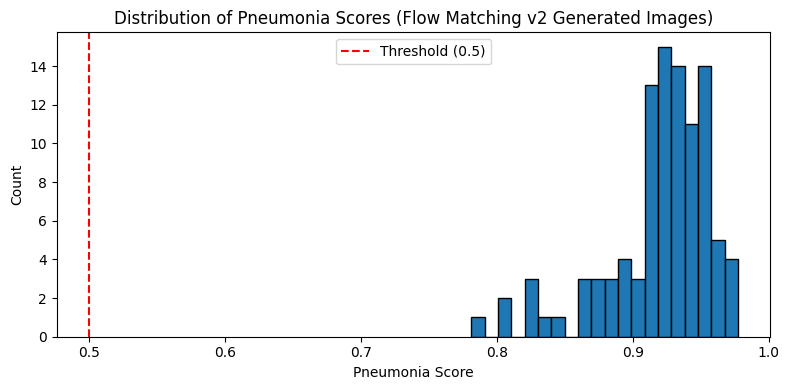

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(pneumonia_scores, bins=20, edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Pneumonia Score')
plt.ylabel('Count')
plt.title('Distribution of Pneumonia Scores (Flow Matching v2 Generated Images)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pneumonia_scores.png", dpi=150)
plt.show()

## Export (images/ + labels.csv + metrics.json)

In [27]:
labels_df = pd.DataFrame({
    'filename': [p.name for p in generated_paths],
    'pneumonia_score': pneumonia_scores,
    'predicted_label': ['pneumonia' if s > threshold else 'normal' for s in pneumonia_scores]
})

for i, name in enumerate(pathology_names):
    labels_df[name] = predictions[:, i]

labels_path = OUTPUT_DIR / "labels.csv"
labels_df.to_csv(labels_path, index=False)
print(f"Saved labels to {labels_path}")

Saved labels to outputs/06_flow_matching_v2/labels.csv


In [28]:
metrics = {
    'model': 'flow_matching_v2',
    'n_generated': len(generated_paths),
    'fid_domain_adapted': fid_score,
    'tstr_accuracy': tstr_accuracy,
    'mean_pneumonia_score': float(pneumonia_scores.mean()),
    'epochs': N_EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'ema_decay': EMA_DECAY,
    'final_loss': train_losses[-1] if train_losses else None,
    'seed': SEED,
    'improvements': [
        'attention layers at 16x16 and 8x8',
        'EMA for stable generation',
        'cosine LR schedule',
        '100 epochs (2x v1)',
        'adaptive ODE solver (dopri5)'
    ]
}

metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {metrics_path}")
print(json.dumps(metrics, indent=2))

Saved metrics to outputs/06_flow_matching_v2/metrics.json
{
  "model": "flow_matching_v2",
  "n_generated": 100,
  "fid_domain_adapted": 6.204777845049774,
  "tstr_accuracy": 100.0,
  "mean_pneumonia_score": 0.9191087484359741,
  "epochs": 100,
  "batch_size": 32,
  "learning_rate": 0.0001,
  "ema_decay": 0.999,
  "final_loss": 0.10951865790796673,
  "seed": 42,
  "improvements": [
    "attention layers at 16x16 and 8x8",
    "EMA for stable generation",
    "cosine LR schedule",
    "100 epochs (2x v1)",
    "adaptive ODE solver (dopri5)"
  ]
}


## Results

In [29]:
print("="*60)
print("FLOW MATCHING v2 RESULTS")
print("="*60)
print(f"Images generated: {len(generated_paths)}")
print(f"Training epochs: {N_EPOCHS}")
print(f"Domain-adapted FID: {fid_score:.2f}")
print(f"Proxy TSTR accuracy: {tstr_accuracy:.1f}%")
print(f"Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"Final loss: {train_losses[-1]:.4f}")
print("="*60)
print("\nImprovements over v1:")
print("  - Attention layers at 16x16 and 8x8 resolutions")
print("  - EMA (decay=0.999) for stable generation")
print("  - Cosine LR schedule (1e-4 -> 1e-6)")
print("  - 100 epochs (2x v1)")
print("  - Adaptive ODE solver (dopri5)")
print("="*60)

FLOW MATCHING v2 RESULTS
Images generated: 100
Training epochs: 100
Domain-adapted FID: 6.20
Proxy TSTR accuracy: 100.0%
Mean pneumonia score: 0.919
Final loss: 0.1095

Improvements over v1:
  - Attention layers at 16x16 and 8x8 resolutions
  - EMA (decay=0.999) for stable generation
  - Cosine LR schedule (1e-4 -> 1e-6)
  - 100 epochs (2x v1)
  - Adaptive ODE solver (dopri5)
